In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
from cycler import cycler

# Define high-contrast color palette
# 1. Deep Blue, 2. Brick Red, 3. Forest Green, 4. Muted Purple, 5. Safety Orange, 
# 6. Chestnut Brown, 7. Raspberry Pink, 8. Slate Gray, 9. Olive Gold, 10. Teal/Cyan

general_colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf' ]
light_colors = ['#0047AB',  '#FF0000',  '#00CC00',  '#9932CC',  '#FF8C00',  '#FF00FF',  '#FFD700',  '#00CED1',  '#FF4500',  '#7FFF00']

# General graph settings
plt.rcParams.update({
    # Font settings
    'font.family': 'sans-serif',          # Universal font family
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], # Fallback fonts
    # 'font.family': 'serif',          # Cambiato da sans-serif a serif
    # 'font.serif': ['Computer Modern', 'Times New Roman', 'DejaVu Serif'], # Lista di font serif
    'mathtext.fontset': 'cm',        # Imposta i simboli matematici nello stile di LaTeX (Computer Modern
    # 'mathtext.fontset': 'stix',           # Makes LaTeX math symbols match the text font style
    
    # Color cycle settings
    'axes.prop_cycle': cycler(color=light_colors), # Sets the default color sequence for multiple lines
    
    # Size and resolution
    # 'axes.titleweight' : 'bold',
    'figure.titleweight' : 'bold',
    'font.size': 14,                      # General font size
    'axes.labelsize': 14,                 # Size of axis labels (x, y)
    'axes.titlesize': 16,                 # Size of the plot title
    'legend.fontsize': 12,                # Legend font size
    
    # Line and marker aesthetics
    'lines.linewidth': 2,                 # Line width
    'lines.markersize': 5,                # Marker size
    'figure.figsize': (10, 6),            # Default figure size
    
    # Grid settings
    'axes.grid': True,                    # Enable grid by default
    'grid.alpha': 0.4,                    # Make grid slightly transparent
    'grid.linestyle': '--',               # Dashed grid style
    'errorbar.capsize': False             # Add caps to error bars
})

# Exercise 11


## Exercise 11.1
### Assignment

In order to make practice with NN, explore how does the previous linear regression depend on the number of epochs, $N_{\mathrm{epochs}}$, the number of data points $N_{\mathrm{train}}$ and on the noise $\sigma$. Try to improve the previous result operating on these parameters.

### Solution

In [3]:
# NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

# Progress bar
from tqdm.notebook import tqdm 


#### Function

$$
f(x)=2x+1
$$

In this exercise I explore:
- Number of epochs, $N_{\mathrm{epochs}}$: I performed every simulation with a large number of epochs (100), compatible with my laptop capacity.
- Noise $\sigma$: I explore different values of $\sigma$ (0.05, 0.1, 0.2, 0.5, 1) at fixed $N_{\mathrm{train}}$.
- Number of data points $N_{\mathrm{train}}$: I explore different values of $N_{\mathrm{train}}$ (30, 100, 500, 5000) at fixed $\sigma$.

Progressione Sigma:   0%|          | 0/5 [00:00<?, ?it/s]

E0000 00:00:1781395689.451079   77014 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


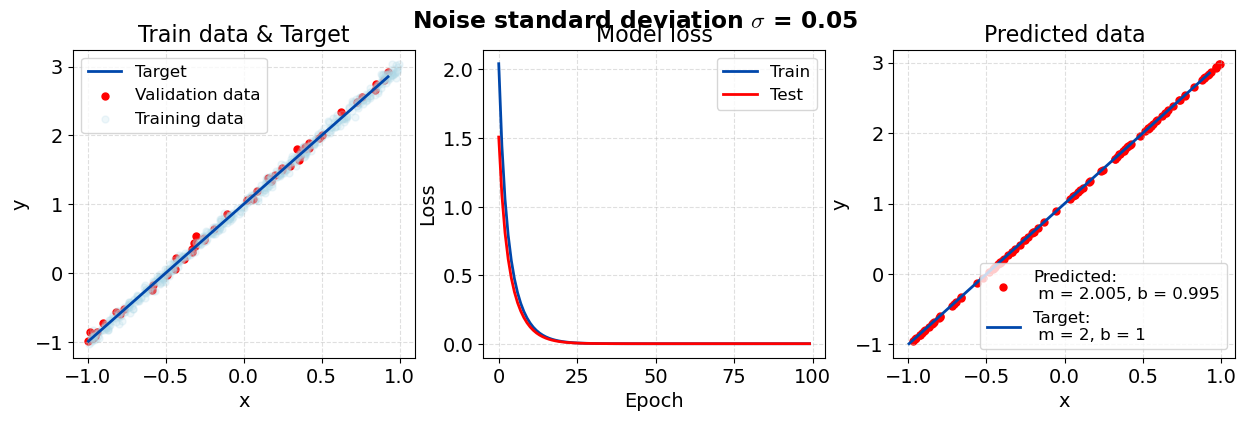

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


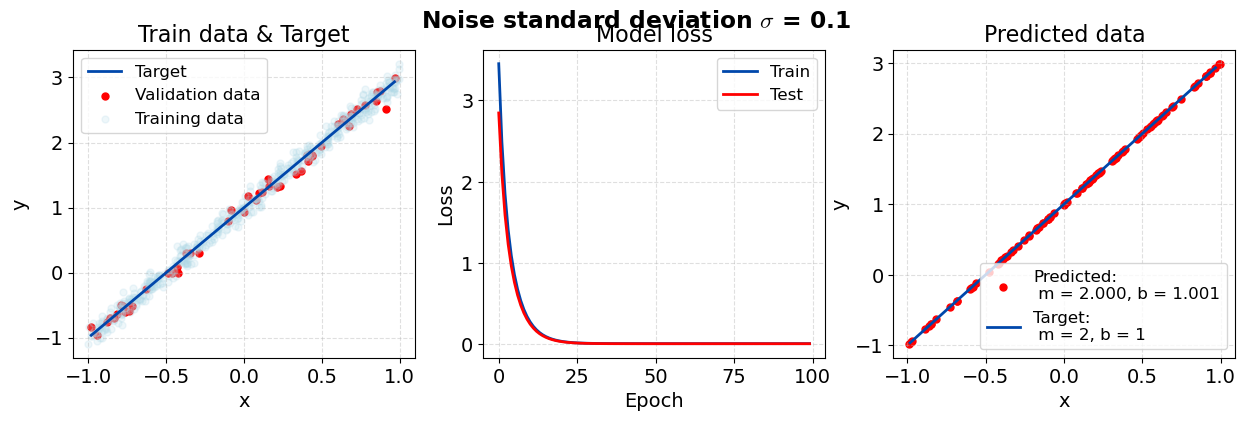

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x787904537560> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


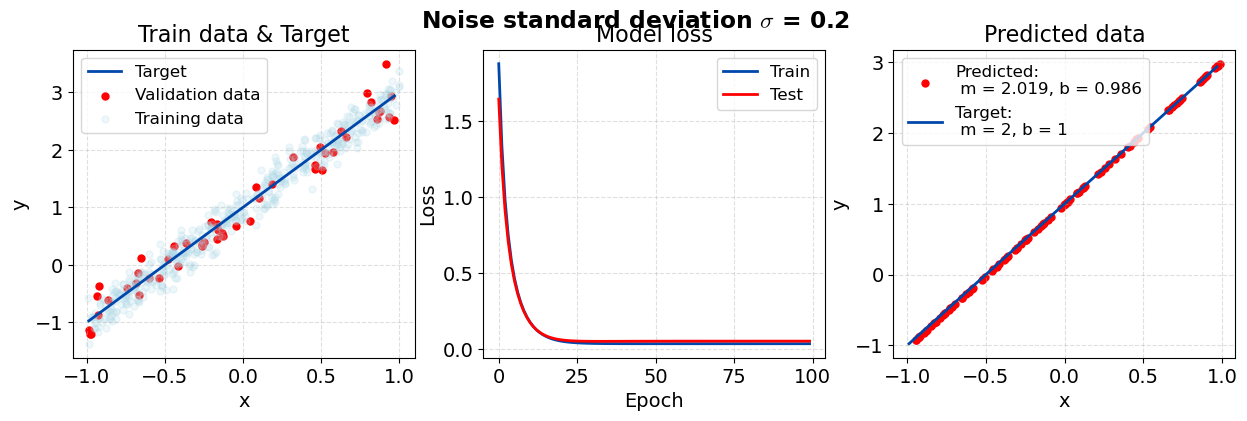

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


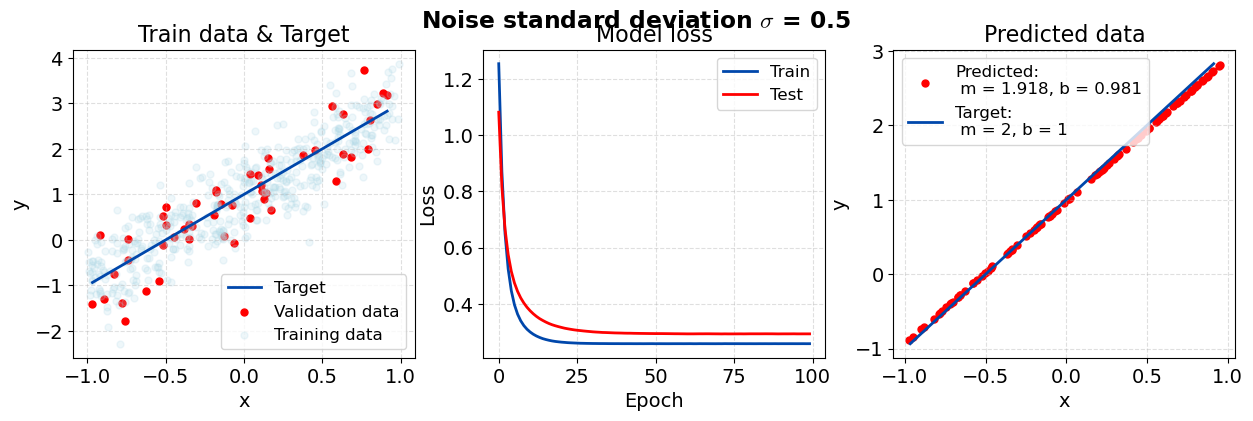

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


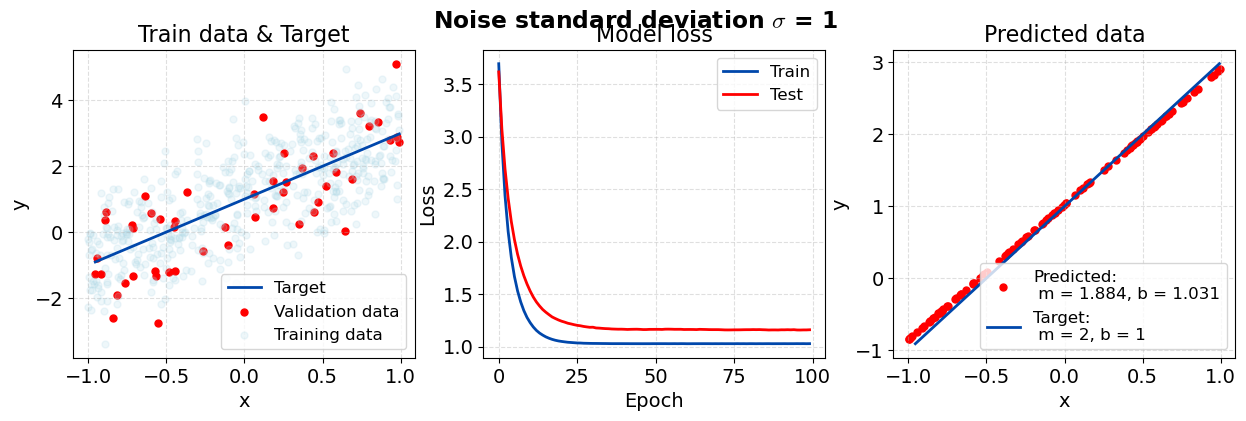

In [ ]:
# target parameters of f(x) = m*x + b

m = 2 # slope
b = 1 # intersect

# Parameters to explore:
sigma_s = [0.05, 0.1, 0.2, 0.5, 1] # noise standard deviation
N_epochs = 100  # I fix a high number of epochs 

# Fraction of data used as validation
val_frac = 0.1

# generate training inputs
np.random.seed(0)

data_size = 500  # initialize data size: for the first analysis I choose a medium-small size, for practicity

# Avvolgi la tua lista sigma_s con tqdm()
for sigma in tqdm(sigma_s, desc="Progressione Sigma"):
    x_train = np.random.uniform(-1, 1, data_size)
    x_valid = np.random.uniform(-1, 1, int(data_size * val_frac))
    x_valid.sort()
    y_target = m * x_valid + b # ideal (target) linear function

    # sigma = 0.2 # noise standard deviation
    y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
    y_valid = np.random.normal(m * x_valid + b, sigma)

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Noise standard deviation $\sigma$ = {sigma}")

    # plot validation and target dataset
    axs[0].plot(x_valid, y_target, label='Target')
    axs[0].scatter(x_valid, y_valid, color='red', label='Validation data')
    axs[0].scatter(x_train, y_train, color='lightblue', label='Training data', alpha=0.2)
    axs[0].set_title('Train data & Target')
    axs[0].set_ylabel('y')
    axs[0].set_xlabel('x')
    axs[0].legend()
    axs[0].grid(True)

    model = tf.keras.Sequential()
    model.add(Input(shape=(1,)))
    model.add(Dense(1))

    # compile the model choosing optimizer, loss and metrics objects
    model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

    # fit the model using training dataset
    # over 10 epochs of 32 batch size each
    # report training progress against validation data
    history = model.fit(x=x_train, y=y_train, 
                        batch_size=32, epochs=N_epochs,
                        shuffle=True, # a good idea is to shuffle input before at each epoch
                        validation_data=(x_valid, y_valid), 
                        verbose=0) # Non stampo niente
    
    # return weights and biases
    weights = model.get_weights()

    m_stimato = weights[0][0][0]  # Accede all'elemento dell'array 2D [[valore]]
    b_stimato = weights[1][0]     # Accede all'elemento dell'array 1D [valore]

    # evaluate model
    score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=0)

    # look into training history
    # Plot training & validation loss values
    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['Train', 'Test'], loc='best')
    axs[1].grid(True)

    x_predicted = np.random.uniform(-1, 1, 100)
    y_predicted = model.predict(x_predicted)
    axs[2].scatter(x_predicted, y_predicted,color='r')
    axs[2].plot(x_valid, y_target)
    axs[2].grid(True)    
    axs[2].set_title('Predicted data')
    axs[2].set_ylabel('y')
    axs[2].set_xlabel('x')
    axs[2].legend([f'Predicted:\n m = {m_stimato:.3f}, b = {b_stimato:.3f}', f'Target:\n m = {m}, b = {b}'], loc='best')

    plt.tight_layout()
    plt.show()




In the first graph it is clearly shown how the noise affects both validation and training data. 
The second type of graphs shows that the more noisy the data is, the higher the loss function gets. This is trivial considered the fact that the loss function taken in account in this exercise is the MSE. Specifically, it goes really fast to zero for $\sigma \leq 0.1$, while when $\sigma = 1$ it doesn't drop under $1$. However, the noisiness of the data doesn't affect the shape of the loss function, that is quite unvaried. 

Unsurprisingly, also the predicted values are quite affected by the noise, becoming more and more unprecise. It is also possible to appreciate that the loss function of the test set has a higher value in comparison to the training one. This is expected since the model has "learned" a bit from the data, and it is impossible for it to perform better on unknown data. 

Progressione N_trial:   0%|          | 0/4 [00:00<?, ?it/s]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


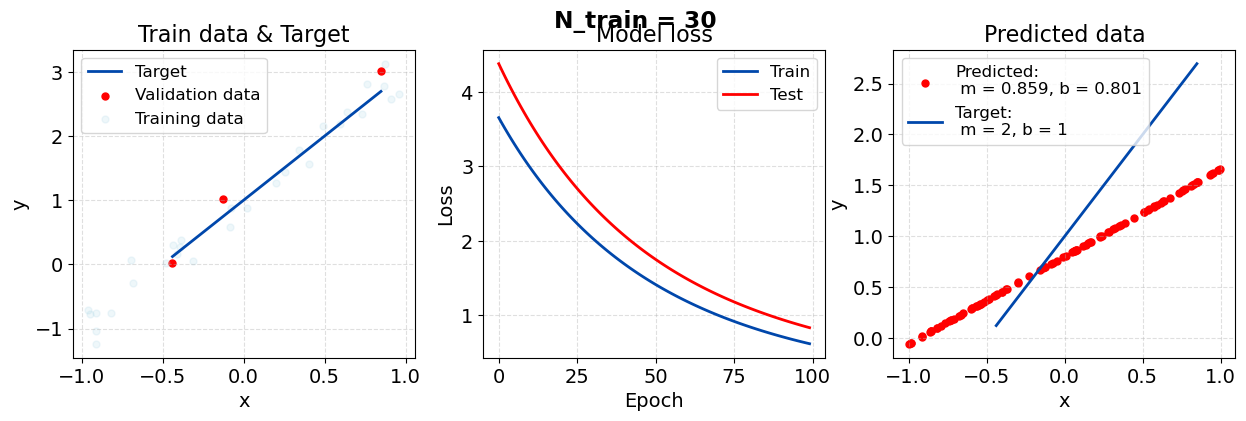

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


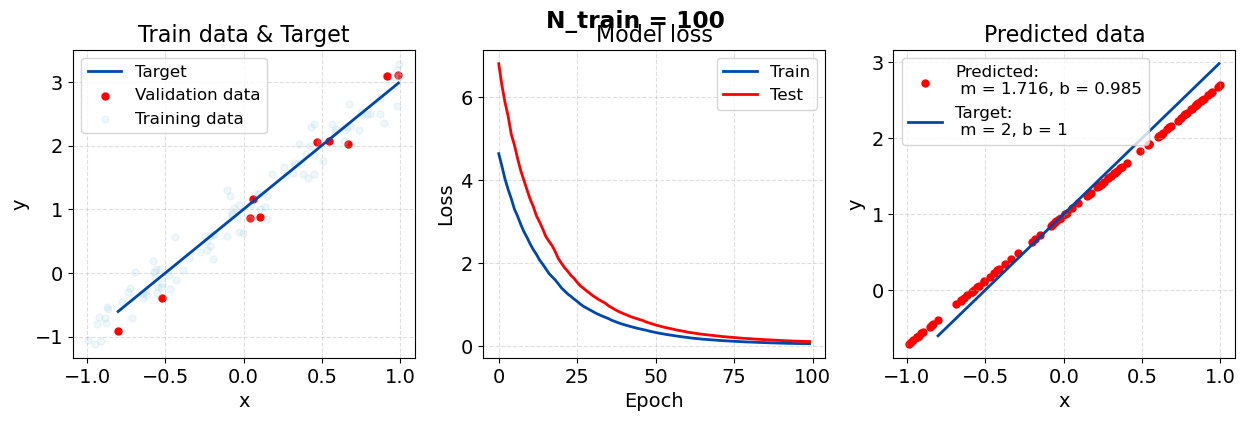

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


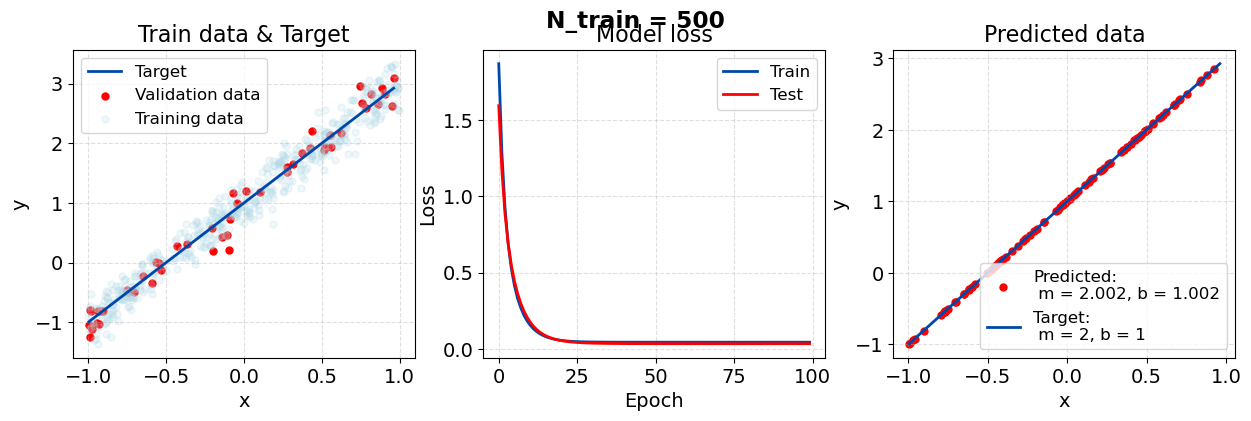

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


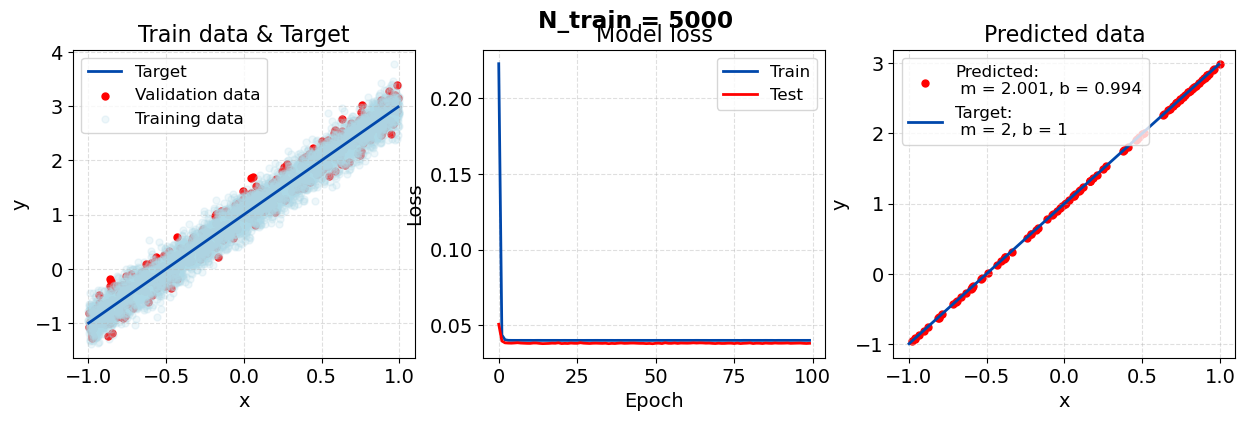

In [ ]:
sigma = 0.2

data_size_s = [30, 100, 500, 5000]   # number of data points

# Avvolgi la tua lista sigma_s con tqdm()
for data_size in tqdm(data_size_s, desc="Progressione N_trial"):
    x_train = np.random.uniform(-1, 1, data_size)
    x_valid = np.random.uniform(-1, 1, int(data_size * val_frac))
    x_valid.sort()
    y_target = m * x_valid + b # ideal (target) linear function

    # sigma = 0.2 # noise standard deviation
    y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
    y_valid = np.random.normal(m * x_valid + b, sigma)

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"N_train = {data_size}")

    # plot validation and target dataset
    axs[0].plot(x_valid, y_target, label='Target')
    axs[0].scatter(x_valid, y_valid, color='red', label='Validation data')
    axs[0].scatter(x_train, y_train, color='lightblue', label='Training data', alpha=0.2)
    axs[0].set_title('Train data & Target')
    axs[0].set_ylabel('y')
    axs[0].set_xlabel('x')
    axs[0].legend()
    axs[0].grid(True)

    model = tf.keras.Sequential()
    model.add(Input(shape=(1,)))
    model.add(Dense(1))

    # compile the model choosing optimizer, loss and metrics objects
    model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

    # fit the model using training dataset
    # over 10 epochs of 32 batch size each
    # report training progress against validation data
    history = model.fit(x=x_train, y=y_train, 
                        batch_size=32, epochs=N_epochs,
                        shuffle=True, # a good idea is to shuffle input before at each epoch
                        validation_data=(x_valid, y_valid), 
                        verbose=0) # Non stampo niente
    
    # return weights and biases
    weights = model.get_weights()

    m_stimato = weights[0][0][0]  # Accede all'elemento dell'array 2D [[valore]]
    b_stimato = weights[1][0]     # Accede all'elemento dell'array 1D [valore]

    # evaluate model
    score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=0)

    # look into training history
    # Plot training & validation loss values
    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['Train', 'Test'], loc='best')
    axs[1].grid(True)

    x_predicted = np.random.uniform(-1, 1, 100)
    y_predicted = model.predict(x_predicted)
    axs[2].scatter(x_predicted, y_predicted,color='r')
    axs[2].plot(x_valid, y_target)
    axs[2].grid(True)    
    axs[2].set_title('Predicted data')
    axs[2].set_ylabel('y')
    axs[2].set_xlabel('x')
    axs[2].legend([f'Predicted:\n m = {m_stimato:.3f}, b = {b_stimato:.3f}', f'Target:\n m = {m}, b = {b}'], loc='best')

    plt.tight_layout()
    plt.show()



As expected, it can be seen in these plots that increasing the amount of training data drastically reduces the loss function of the single-neuron network, resulting in a significant increase in accuracy. The loss function speeds towards zero as the number of data increases, meaning that the learning process is strictly related to the number of data, as one wuould expect. 

## Exercise 11.2
### Assignment

Try to extend the model to obtain a reasonable fit of the following polynomial of order 3:

$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$.

Find good (& reasonable) choices for:

- the number of layers
- the number of neurons in each layer
- the activation function
- the optimizer
- the loss function
  
Check your NN model by seeing how well your fits predict newly generated test data (including on data outside the range you fit). How well do your NN do on points in the range of $x$ where you trained the model? How about points outside the original training data set? 
Summarize what you have learned about the relationship between model complexity (number of parameters), goodness of fit on training data, and the ability to predict well.

### Solution

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.models import load_model

# Progress bar
from tqdm.notebook import tqdm 

For this exercise I first wanted to see how the smallest possible network would have performed. To do so I create a NN with only:
- 4 input neuron, each accepts a single value
- 1 output neuron
I tried to do it this small because I wanted to test how many neurons would have been necessary to get 4 parameters instead of 1, and I thought that 2 neurons activated with the sigmoid function would have been the minimum to do a double bump to the function. I thought about the sigma function because it is smooth as the target.

/home/giacomo/miniconda3/envs/lsn_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.7533 - mse: 0.7533

Test loss: 0.7532553672790527
Test accuracy: 0.7532553672790527
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


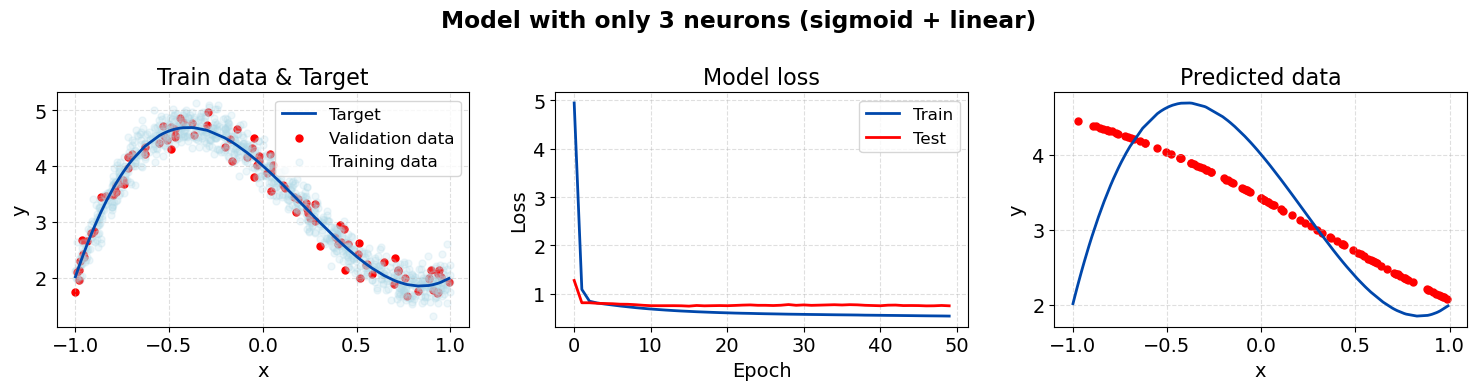

In [9]:
# target parameters of f(x) = ax^3 + bx^2 + cx + d
a = 3
b = -2
c = -3
d = 4

model = Sequential()

# model = tf.keras.Sequential() # Dovrebbe essere equivalente
# Adds to the model a mono layer with 2 units with input shape 1
model.add(Dense(4, input_shape=(1,), activation='sigmoid'))
model.add(Dense(1, activation='linear'))

N_epochs = 50  # number of epochs 

# Fraction of data used as validation
val_frac = 0.1

# generate training inputs
np.random.seed(0)

data_size = 1000  # data size

###
x_train = np.random.uniform(-1, 1, data_size)
x_valid = np.random.uniform(-1, 1, int(data_size * val_frac))
x_valid.sort()
y_target = a * x_valid**3 + b * x_valid**2 + c * x_valid + d  # ideal (target) function

sigma = 0.2 # noise standard deviation
y_train = np.random.normal(a * x_train**3 + b * x_train**2 + c * x_train + d, sigma) # actual measures
y_valid = np.random.normal(a * x_valid**3 + b * x_valid**2 + c * x_valid + d, sigma)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Model with only 3 neurons (sigmoid + linear)")

# plot validation and target dataset
axs[0].plot(x_valid, y_target, label='Target')
axs[0].scatter(x_valid, y_valid, color='red', label='Validation data')
axs[0].scatter(x_train, y_train, color='lightblue', label='Training data', alpha=0.2)
axs[0].set_title('Train data & Target')
axs[0].set_ylabel('y')
axs[0].set_xlabel('x')
axs[0].legend()
axs[0].grid(True)

# Configure the model for mean-squared error regression.
model.compile(optimizer='sgd',       # stochastic gradient descent
            loss='mse',
            metrics=['mse'])  # list of metrics

# Riassunto
model.summary()

bsize = 32
# fit the model using training dataset
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
        batch_size=bsize, epochs=N_epochs, shuffle=True,
        validation_data=(x_valid, y_valid), 
        verbose=0)

# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=bsize, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# look into training history
# Plot training & validation loss values
axs[1].plot(history.history['loss'])
axs[1].plot(history.history['val_loss'])
axs[1].set_title('Model loss')
axs[1].set_ylabel('Loss')
axs[1].set_xlabel('Epoch')
axs[1].legend(['Train', 'Test'], loc='best')
axs[1].grid(True)

x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
axs[2].scatter(x_predicted, y_predicted,color='r')
axs[2].plot(x_valid, y_target)
axs[2].grid(True)    
axs[2].set_title('Predicted data')
axs[2].set_ylabel('y')
axs[2].set_xlabel('x')

plt.tight_layout()
plt.show()

As one could have expected, the result isn't very good, meaning that the number of neurons might have the ability to learn up to 13 parameters, as stated in the summary, but this might not be possible with a reasonable amount of data.


## Neural Network Architecture

### General Heuristics and Literature Suggestions
When designing the architecture of a Multi-Layer Perceptron (MLP), standard literature provides a few practical guidelines:
- Network Depth: For relatively simple regression and classification tasks, a shallow architecture (typically 2 to 3 hidden layers) is usually sufficient to capture the underlying patterns without incurring overfitting or vanishing gradients.
- Layer Width (Neurons): A common empirical rule is to gradually decrease the number of neurons as the network progresses towards the output layer. Furthermore, utilizing powers of 2 (e.g., 16, 32, 64) for the layer width can help optimize memory allocation.

### Fixed Architectural Constraints
Given the specific nature of the problem, some parameters are dictated by the task:
- Output Layer Size: Exactly 1 neuron, since the goal is to predict a single continuous variable (1D regression).
- Output Activation Function: Linear (Identity). Standard for regression tasks.
- Loss Function: Mean Squared Error (MSE), which is the standard and most appropriate metric for regression models.



### Grid Search
I defined an architecture consisting of 2 hidden layers with 32 neurons each.
I opted for an automated empirical approach. I implemented a nested for loop to train the network across all possible combinations of a set of activation functions for the two hidden layers, aiming to identify the most performing configuration.

In [ ]:
# Target parameters of f(x) = ax^3 + bx^2 + cx + d
a = 3
b = -2
c = -3
d = 4

act_functions = ['elu', 'sigmoid', 'linear', 'relu', 'tanh']
n_tot_to_explore = len(act_functions)**2

risultati = []          # List to save the raw configuration performance data
risultati_ordinati = []  # List to save the sorted configuration performance data

N_epochs = 30       # Number of training epochs
val_frac = 0.1       # Fraction of data used for validation
np.random.seed(0)    # Initialize random number generator seed
data_size = 1000     # Size of the dataset
bsize = 32           # Batch size

# Generating datasets
x_train = np.random.uniform(-1, 1, data_size)
x_valid = np.random.uniform(-1, 1, int(data_size * val_frac))
x_valid.sort()
y_target = a * x_valid**3 + b * x_valid**2 + c * x_valid + d  # Ideal analytical target function

sigma = 0.2  # Noise standard deviation
y_train = np.random.normal(a * x_train**3 + b * x_train**2 + c * x_train + d, sigma)  # Noisy training measurements
y_valid = np.random.normal(a * x_valid**3 + b * x_valid**2 + c * x_valid + d, sigma)

best_loss = float('inf')  # Initialize best error metrics to infinity
worst_loss = 0.0          # Initialize worst error metrics to zero
best_history = None
worst_history = None

count = 0

# Grid search loop over activation function combinations
for f_layer1 in act_functions:

    for f_layer2 in act_functions:

        count += 1

        # Clear session to prevent memory leaks across iterations
        tf.keras.backend.clear_session()

        # Build network architecture
        model = Sequential()
        model.add(Dense(32, input_shape=(1,), activation=f_layer1))
        model.add(Dense(32, activation=f_layer2))
        model.add(Dense(1, activation='linear'))

        # Configure the model for mean-squared error regression
        model.compile(optimizer='sgd',
                      loss='mse',
                      metrics=['mse'])

        # Fit the model using the training dataset and evaluate against validation data
        history = model.fit(x=x_train, y=y_train, 
                            batch_size=bsize, epochs=N_epochs, shuffle=True,
                            validation_data=(x_valid, y_valid), 
                            verbose=0)

        # Extract the final validation loss value
        final_val_loss = history.history['val_loss'][-1]

        # Save the current combination risultati
        risultati.append({
            'combo': f"{f_layer1} + {f_layer2}",
            'loss': final_val_loss
        })

        # Track and update the top performing network configuration
        if final_val_loss < best_loss:
            best_loss = final_val_loss
            best_history = history.history
            
            model.save('best_cubic_model.keras')
            print(f"⭐ New best record set by model {count}/{n_tot_to_explore}! Loss: {best_loss:.4f} (Saved model as best_cubic_model.keras)")
        
        # Track and update the poorest performing network configuration
        if final_val_loss > worst_loss:
            worst_loss = final_val_loss
            worst_history = history.history
            
            model.save('worst_cubic_model.keras')
            print(f"[x] New worst record set by model {count}/{n_tot_to_explore}! Loss: {worst_loss:.4f} (Saved model as worst_cubic_model.keras)")

risultati_ordinati = risultati
# Find and display the optimal parameter combination
# Use sorted() to CREATE A SORTED COPY, leaving the original list ordering intact
# ATT: this passage is important, if i used sort(), I would sort the original object
risultati_ordinati = sorted(risultati, key=lambda x: x['loss'])

print("-" * 30)
print(f"🏆 Best combo is: {risultati_ordinati[0]['combo']} with Loss: {risultati_ordinati[0]['loss']:.4f}")



/home/giacomo/miniconda3/envs/lsn_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1781427915.372165    1185 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


⭐ New best record set by model 1/25! Loss: 0.1830 (Saved model as best_cubic_model.keras)
[x] New worst record set by model 1/25! Loss: 0.1830 (Saved model as worst_cubic_model.keras)
[x] New worst record set by model 2/25! Loss: 0.7272 (Saved model as worst_cubic_model.keras)
⭐ New best record set by model 4/25! Loss: 0.1126 (Saved model as best_cubic_model.keras)
[x] New worst record set by model 6/25! Loss: 0.7773 (Saved model as worst_cubic_model.keras)
[x] New worst record set by model 7/25! Loss: 0.8546 (Saved model as worst_cubic_model.keras)
[x] New worst record set by model 9/25! Loss: 0.8893 (Saved model as worst_cubic_model.keras)
⭐ New best record set by model 14/25! Loss: 0.1021 (Saved model as best_cubic_model.keras)
⭐ New best record set by model 15/25! Loss: 0.0933 (Saved model as best_cubic_model.keras)
⭐ New best record set by model 16/25! Loss: 0.0824 (Saved model as best_cubic_model.keras)
⭐ New best record set by model 20/25! Loss: 0.0736 (Saved model as best_cubic

The grid search revealed that, given our current architecture and hyperparameter setup, the optimal combination of activation functions is **relu + tanh**, which achieved the lowest Validation Loss of $0.0736$. I saved this optimal configuration as best_cubic_model.keras to efficiently load and evaluate it in the upcoming cells without needing to retrain. Moreover, I deliberately tracked and saved the worst-performing architecture (the one with the highest loss) as worst_cubic_model.keras. Then I compare the absolute best and the absolute worst models to visually demonstrate the network's ability/inability to fit the cubic data.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


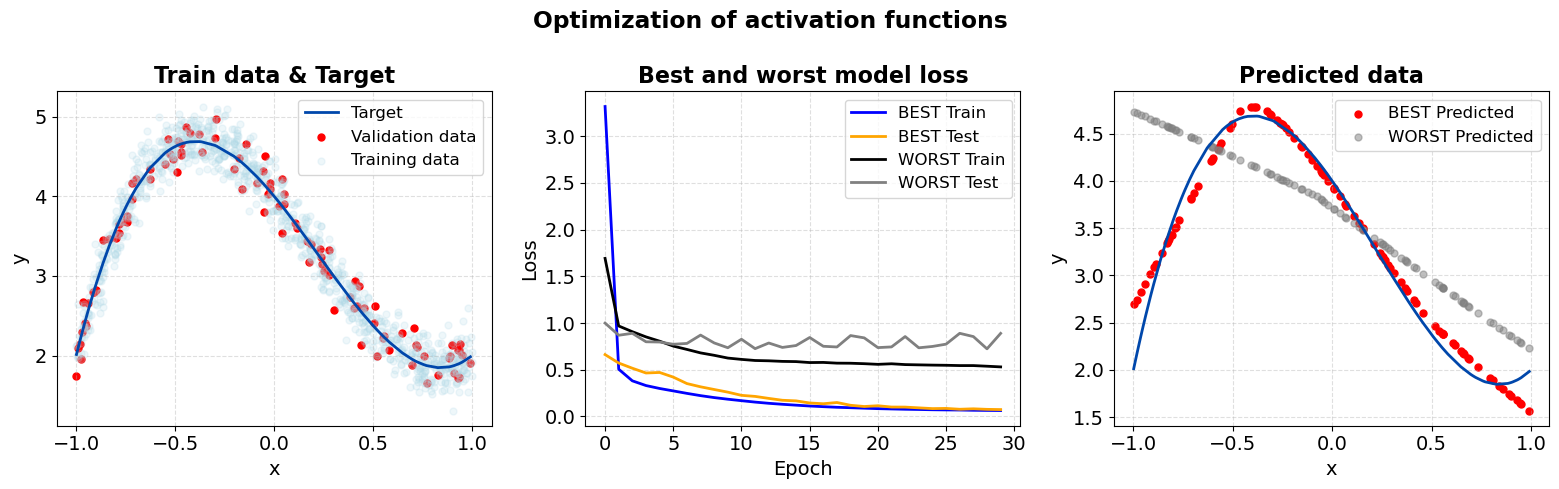

In [20]:
from tensorflow.keras.models import load_model

### visualization
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Optimization of activation functions")

# plot validation and target dataset
axs[0].plot(x_valid, y_target, label='Target')
axs[0].scatter(x_valid, y_valid, color='red', label='Validation data')
axs[0].scatter(x_train, y_train, color='lightblue', label='Training data', alpha=0.2)
axs[0].set_title('Train data & Target')
axs[0].set_ylabel('y')
axs[0].set_xlabel('x')
axs[0].legend()
axs[0].grid(True)


# look into training historybest_cubic_model.keras
# Plot training & validation loss values
axs[1].plot(best_history['loss'], color="blue")
axs[1].plot(best_history['val_loss'], color="orange")
axs[1].plot(worst_history['loss'], color="black")
axs[1].plot(worst_history['val_loss'], color="grey")
axs[1].set_title('Best and worst model loss')
axs[1].set_ylabel('Loss')
axs[1].set_xlabel('Epoch')
axs[1].legend(['BEST Train', 'BEST Test', 'WORST Train', 'WORST Test'], loc='best')
axs[1].grid(True)


n_to_predict = 100
x_predicted = np.random.uniform(-1, 1, n_to_predict)
best_y_predicted = np.zeros(n_to_predict)
worst_y_predicted = np.zeros(n_to_predict)

best_model = load_model('best_cubic_model.keras')
worst_model = load_model('worst_cubic_model.keras')
best_y_predicted = best_model.predict(x_predicted)
worst_y_predicted = worst_model.predict(x_predicted)

axs[2].scatter(x_predicted, best_y_predicted, color='r')
axs[2].scatter(x_predicted, worst_y_predicted, color='grey', alpha=0.5)
axs[2].plot(x_valid, y_target)
axs[2].grid(True)    
axs[2].set_title('Predicted data')
axs[2].set_ylabel('y')
axs[2].set_xlabel('x')
axs[2].legend(['BEST Predicted', 'WORST Predicted'], loc='best')

plt.tight_layout()
plt.show()

From the image it is clear that now the NN is deep enough to learn the shape of the cubic function. I also reported the worst prediction, for comparison, and it is clearly visible that the worst model isn't capable at all to learn the data shape, despite the discrete number of parameters in the NN. 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


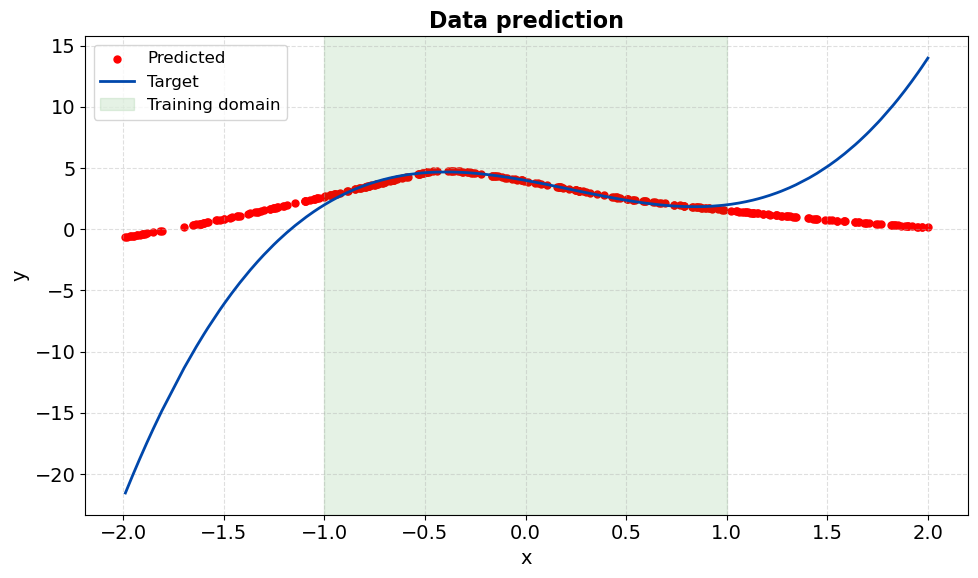

In [19]:
from tensorflow.keras.models import load_model

n_to_predict = 300
x_predicted = np.random.uniform(-2, 2, n_to_predict)
x_predicted.sort()
y_exact = a * x_predicted**3 + b * x_predicted**2 + c * x_predicted + d  # ideal (target) function
best_y_predicted = np.zeros(n_to_predict)

best_model = load_model('best_cubic_model.keras')
best_y_predicted = best_model.predict(x_predicted)

plt.scatter(x_predicted, best_y_predicted, color='r', label='Predicted')
plt.plot(x_predicted, y_exact, label='Target')
plt.grid(True)    
plt.title('Data prediction')
plt.ylabel('y')
plt.xlabel('x')
plt.axvspan(-1, 1, color='green', alpha=0.1, label='Training domain')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

It is clear from the image that the network has "learned" quite well the shape of the function in the range where it has been trained, but isn't able to predict data in regions where it has never seen data.

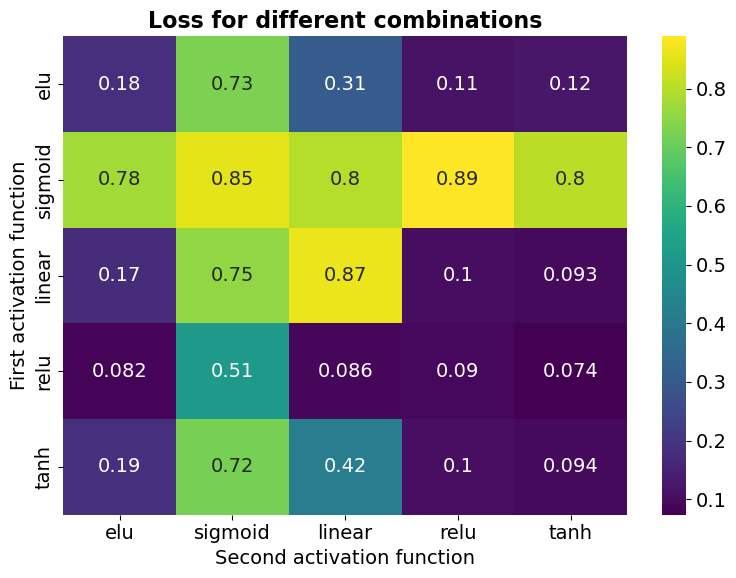

In [18]:
import seaborn as sns
data = None

n = len(risultati)
data = np.zeros(n)
label = np.zeros(n)

for i in range(n) : 
    data[i] = configurazione = risultati[i]['loss']

loss_matrix = data.reshape(len(act_functions), len(act_functions))

plt.figure(figsize=(8, 6))
sns.heatmap(loss_matrix, annot=True, cmap='viridis', 
            xticklabels=act_functions, yticklabels=act_functions) # annot=True mostra i numeri nelle celle

plt.title("Loss for different combinations")
plt.xlabel("Second activation function")
plt.ylabel("First activation function")
plt.grid(False)
plt.tight_layout()
plt.show()

Here is shown a summary heatmap of the training. It is clear also that the **relu + tanh" activation combo is the best in this training. Other significant info that is possible to collect from the image are:
- Sigmoid actiovation function is the function with the worst performance. It has a loss function even higher than the model with only linear activation functions, that is quite odd, considered that the sigmoid function contains some unlinearity, unlike the identity function.
- Relu activation function is possibly the one with the best average performance, and the **relu+relu** combo is one of the best possibilities.

To sum up, the more complex the model is, the better it will fit the training data. This however, can be a problem, because if the model memorizes the data, then it will overfit it - in the case of a regression problem - or not be able to generalize the important features - in the case of a categorization problem. In any case, the model wil be useless, because it will only perform well on train data and will be useless on new data. 

Moreover, it seems that the NNs I created weren't able to work on data outside the range they were trained. This shows that the "learning" of the model is more similar to a "generalizing" of data, rather than an actual extrapolating the features. 

## Exercise 11.3
### Assignment

Try to extend the model to fit a simple trigonometric 2D function such as $f(x,y) = \sin(x^2+y^2)$ in the range $x \in [-3/2,3/2]$ and $y \in [-3/2,3/2]$.

### Solution

### Neural network architecture
I implement here a NN following the steps used before with two layers, each with 32 neurons. I now have to modify the input size to 2 instead of 1. I execute the same grid search, removing the linear activation function from the options, in accord with previous findings.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.models import load_model

# Progress bar
from tqdm.notebook import tqdm 

In [25]:
act_functions = ['relu', 'elu', 'sigmoid', 'tanh']
n_tot_to_explore = len(act_functions)**2

risultati = [] # list to save the information about the combination
risultati_ordinati = [] # list to save the ORDERED information about the combination

N_epochs = 30 # number of epochs 
val_frac = 0.1 # fraction of data used as validation
np.random.seed(0) # init rand gen
data_size = 1000 # data size
n_input = 2
bsize = 32 # batch size

# Generating data
x_train = np.random.uniform(-3/2, 3/2, size=(data_size, n_input))
x_valid = np.random.uniform(-3/2, 3/2, size=(int(data_size * val_frac), n_input))
z_target = np.sin(x_valid[:, 0]**2 + x_valid[:, 1]**2)  # ideal (target) function

sigma = 0.2 # noise standard deviation
z_train = np.random.normal(np.sin(x_train[:, 0]**2 + x_train[:, 1]**2), sigma) # actual measures
z_valid = np.random.normal(np.sin(x_valid[:, 0]**2 + x_valid[:, 1]**2), sigma)

best_loss = float('inf') # initial error set at infinite
best_history = None

count = 0

for f_layer1 in act_functions:

    for f_layer2 in act_functions:

        count+= 1

        tf.keras.backend.clear_session()

        model = Sequential()
        # Adds to the model a mono layer with 2 units with input shape 2
        model.add(Dense(32, input_shape=(2,), activation=f_layer1))
        model.add(Dense(32, activation=f_layer2))
        model.add(Dense(1, activation='linear'))

        # Configure the model for mean-squared error regression.
        model.compile(optimizer='sgd',
                    loss='mse',
                    metrics=['mse']) # list of metrics

        # fit the model using training dataset
        # report training progress against validation data
        history = model.fit(x=x_train, y=z_train, 
                batch_size=bsize, epochs=N_epochs, shuffle=True,
                validation_data=(x_valid, z_valid), 
                verbose=0)

        # Valuta la performance finale
        final_val_loss = history.history['val_loss'][-1]

        # Salva il risultato
        risultati.append({
            'combo': f"{f_layer1} + {f_layer2}",
            'loss': final_val_loss
        })

        if final_val_loss < best_loss :
            best_loss = final_val_loss
            best_history = history.history
            

            model.save('best_trigon_model.keras')
            print(f"⭐ New best record set by model {count}/{n_tot_to_explore}! Loss: {best_loss:.4f} (Saved model as best_trigon_model.keras)")

# trova e stampa la configurazione migliore
risultati_ordinati = risultati
# Find and display the optimal parameter combination
# Use sorted() to CREATE A SORTED COPY, leaving the original list ordering intact
# ATT: this passage is important, if i used sort(), I would sort the original object
risultati_ordinati = sorted(risultati, key=lambda x: x['loss'])

print("-" * 30)
print(f"🏆 LA COMBINAZIONE MIGLIORE È: {risultati_ordinati[0]['combo']} con Loss: {risultati_ordinati[0]['loss']:.4f}")



⭐ New best record set by model 1/16! Loss: 0.1522 (Saved model as best_trigon_model.keras)
------------------------------
🏆 LA COMBINAZIONE MIGLIORE È: relu + relu con Loss: 0.1522


In [26]:
print(risultati_ordinati)
print(risultati)

[{'combo': 'relu + relu', 'loss': 0.15217886865139008}, {'combo': 'tanh + relu', 'loss': 0.15846744179725647}, {'combo': 'relu + tanh', 'loss': 0.16582025587558746}, {'combo': 'relu + elu', 'loss': 0.17108575999736786}, {'combo': 'elu + relu', 'loss': 0.17741580307483673}, {'combo': 'tanh + tanh', 'loss': 0.1846180409193039}, {'combo': 'relu + sigmoid', 'loss': 0.1883733719587326}, {'combo': 'elu + elu', 'loss': 0.18947261571884155}, {'combo': 'tanh + elu', 'loss': 0.19211100041866302}, {'combo': 'elu + tanh', 'loss': 0.19218307733535767}, {'combo': 'tanh + sigmoid', 'loss': 0.19248932600021362}, {'combo': 'sigmoid + sigmoid', 'loss': 0.19271020591259003}, {'combo': 'sigmoid + tanh', 'loss': 0.1928272694349289}, {'combo': 'sigmoid + elu', 'loss': 0.19369371235370636}, {'combo': 'elu + sigmoid', 'loss': 0.1945447474718094}, {'combo': 'sigmoid + relu', 'loss': 0.20231540501117706}]
[{'combo': 'relu + relu', 'loss': 0.15217886865139008}, {'combo': 'relu + elu', 'loss': 0.17108575999736786

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


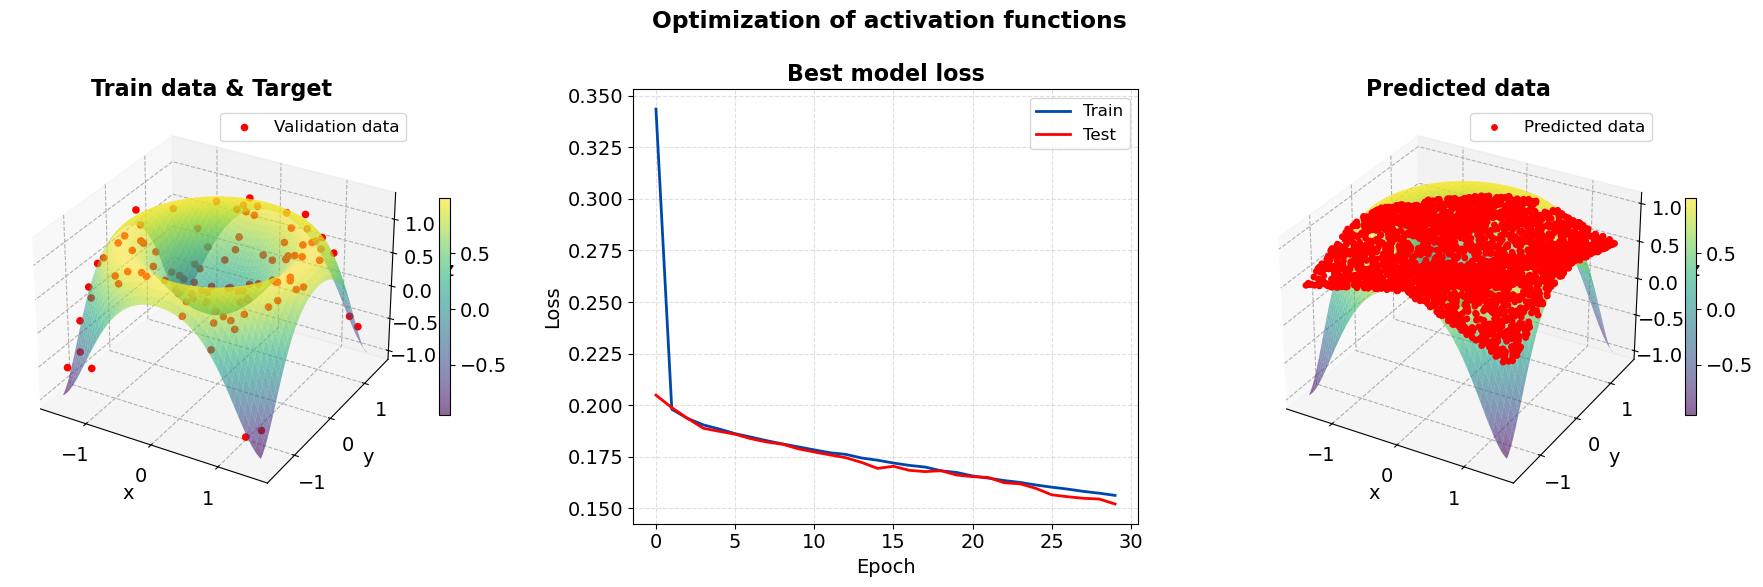

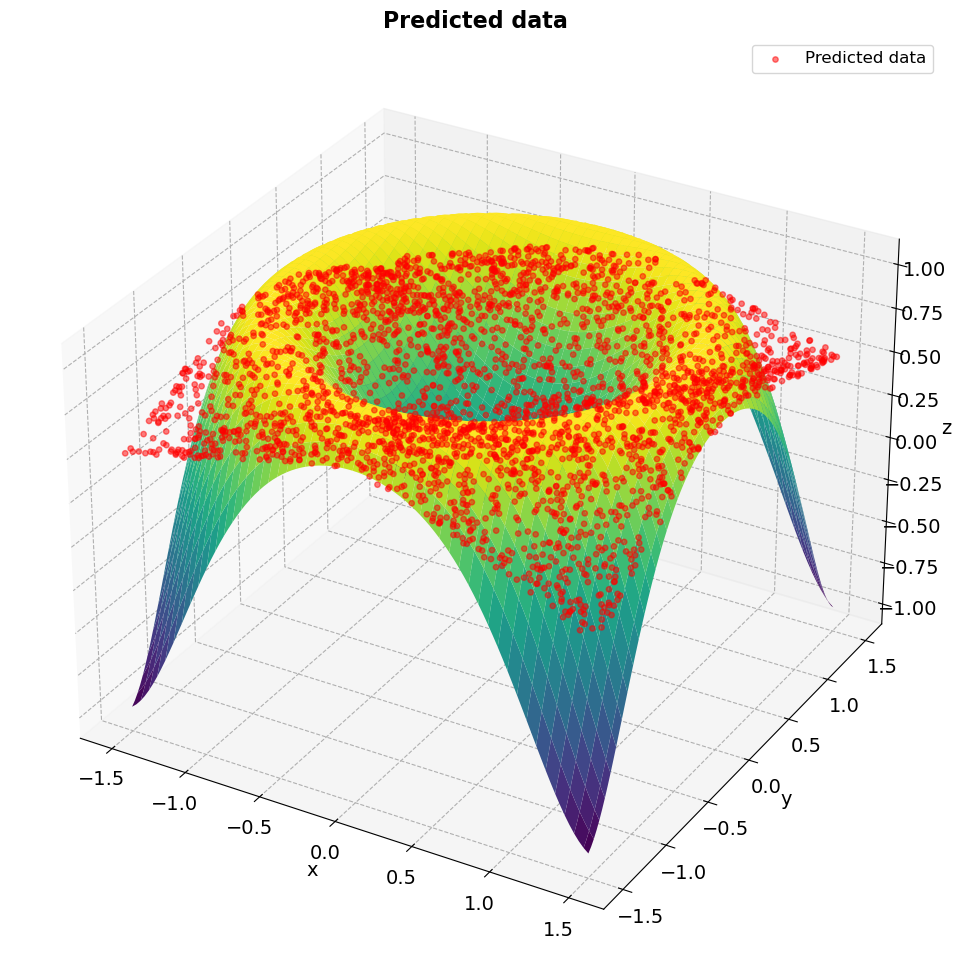

In [ ]:
from tensorflow.keras.models import load_model

x_grid = np.linspace(-1.5, 1.5, 100)
y_grid = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z_true = np.sin(X**2 + Y**2)

### visualization
fig = plt.figure(figsize=(18, 6))
fig.suptitle("Optimization of activation functions")

# 3 subplot 3D
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2) # Questo può restare 2D per la loss
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# plot validation and target dataset
surf_1 = ax1.plot_surface(X, Y, Z_true, cmap='viridis', alpha=0.6)
ax1.scatter(x_valid[:, 0], x_valid[:, 1], z_valid, color='red', label='Validation data', alpha=1)
# ax1.scatter(x_train[:, 0], x_train[:, 1], z_train, color='lightblue', label='Training data', alpha=0.2)
ax1.set_title('Train data & Target')
ax1.set_ylabel('y')
ax1.set_xlabel('x')
ax1.set_zlabel('z')
ax1.legend()
ax1.grid(True)


# look into training historybest_cubic_model.keras
# Plot training & validation loss values
ax2.plot(best_history['loss'], label='Train')
ax2.plot(best_history['val_loss'], label='Test')
ax2.set_title('Best model loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)


n_to_predict = 3000
x_predicted = np.random.uniform(-1.5, 1.5, size=(n_to_predict, n_input)) 

best_model = load_model('best_trigon_model.keras')

# Cflatten() transforms (300,1) in (300,)
best_z_predicted = best_model.predict(x_predicted).flatten()


surf_3 = ax3.plot_surface(X, Y, Z_true, cmap='viridis', alpha=0.6)

ax3.scatter(x_predicted[:, 0], x_predicted[:, 1], best_z_predicted, color='red', label='Predicted data', s=15, alpha=1.0)
#surf_3 = ax3.plot_trisurf(x_valid[:, 0], x_valid[:, 1], z_target, label='Target', cmap='viridis')
ax3.grid(True)    
ax3.set_title('Predicted data')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('z')
ax3.legend()

# Colorbar
fig.colorbar(surf_1, ax=ax1, shrink=0.5)
fig.colorbar(surf_3, ax=ax3, shrink=0.5)


plt.tight_layout()

plt.show()

fig = plt.figure(figsize=(10, 10))
ax4 = fig.add_subplot(1, 1, 1, projection='3d')
ax4.plot_surface(X, Y, Z_true, cmap='viridis', alpha=1)
ax4.scatter(x_predicted[:, 0], x_predicted[:, 1], best_z_predicted, color='red', label='Predicted data', s=15, alpha=0.5)

ax4.grid(True)    
ax4.set_title('Predicted data')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_zlabel('z')
ax4.legend()
plt.tight_layout()
plt.show()

The model works well also with 2D function, with quite the same amount of data points and layers. This shows that the network can work on data of different size, and confirms the strenght of the tool.
Although not very big, the simulation took about 3 min to train, due to the grid search. It is possible to enlarge the number of training data (e.g. 5000) and of epochs (e.g. 50) to get better results.
